# Eksperimen MSML - Titanic Survival Prediction

**Nama Siswa:** Joshua Christian Benedict  
**Dataset:** Titanic Passenger Survival  
**Sumber:** Kaggle - Titanic Dataset  
**Tipe Problem:** Binary Classification (Survived: 0 = No, 1 = Yes)

# 1. Perkenalan Dataset

Dataset Titanic berisi **data penumpang kapal Titanic** dengan informasi demografis dan perjalanan.

**Kolom Dataset:**
| Kolom | Tipe | Deskripsi |
|-------|------|-----------|
| PassengerId | int | ID unik penumpang (akan di-drop) |
| Survived | int | Target: 0 = Tidak selamat, 1 = Selamat |
| Pclass | int | Kelas tiket (1 = 1st, 2 = 2nd, 3 = 3rd) |
| Name | str | Nama penumpang (akan di-drop) |
| Sex | str | Jenis kelamin (male / female) |
| Age | float | Usia penumpang (ada missing values) |
| SibSp | int | Jumlah saudara/pasangan di kapal |
| Parch | int | Jumlah orang tua/anak di kapal |
| Ticket | str | Nomor tiket (akan di-drop) |
| Fare | float | Harga tiket |

**Tujuan:** Memprediksi apakah seorang penumpang selamat (Survived=1) atau tidak (Survived=0) berdasarkan fitur demografis dan tiket.

# 2. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('Library berhasil diimport.')
print(f'Pandas  : {pd.__version__}')
print(f'NumPy   : {np.__version__}')

Library berhasil diimport.
Pandas  : 2.2.2
NumPy   : 2.0.2


# 3. Memuat Dataset

In [3]:
# Load dataset
df = pd.read_csv('./titanic_raw/titanic.csv')

print('=== Info Dataset ===')
print(f'Shape: {df.shape}')
print(f'Kolom: {df.columns.tolist()}')
print()
df.head()

=== Info Dataset ===
Shape: (891, 12)
Kolom: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
print('=== Tipe Data ===')
df.info()
print()
print('=== Statistik Deskriptif ===')
df.describe()

=== Tipe Data ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

=== Statistik Deskriptif ===


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
# Distribusi kelas target
print('=== Distribusi Target (Survived) ===')
print(df['Survived'].value_counts())
print()
print('Persentase:')
vc = df['Survived'].value_counts(normalize=True) * 100
print(f"  Tidak Selamat (0): {vc[0]:.2f}%")
print(f"  Selamat       (1): {vc[1]:.2f}%")

=== Distribusi Target (Survived) ===
Survived
0    549
1    342
Name: count, dtype: int64

Persentase:
  Tidak Selamat (0): 61.62%
  Selamat       (1): 38.38%


# 4. Exploratory Data Analysis (EDA)

In [6]:
# 4.1 Cek Missing Values
print('=== Missing Values ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Percentage (%)': missing_pct})
print(missing_df[missing_df['Count'] > 0])

=== Missing Values ===
          Count  Percentage (%)
Age         177           19.87
Cabin       687           77.10
Embarked      2            0.22


In [7]:
# 4.2 Cek Duplikat
print(f'Jumlah duplikat: {df.duplicated().sum()}')

Jumlah duplikat: 0


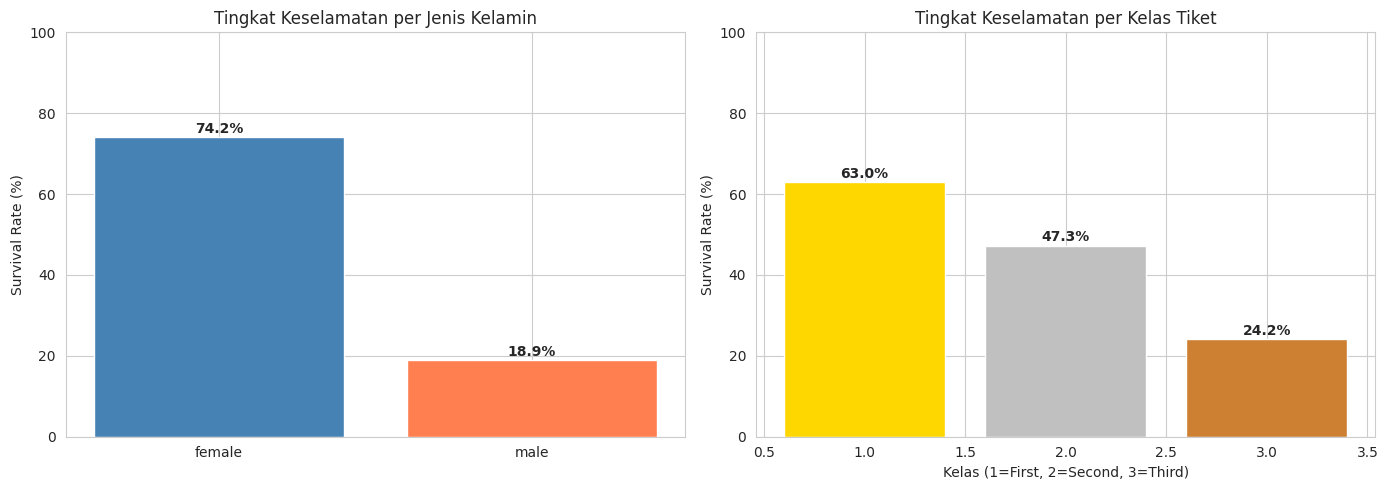

Plot survival by category tersimpan.


In [8]:
# 4.3 Distribusi Survival rate berdasarkan Sex
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Survival by Sex
survival_sex = df.groupby('Sex')['Survived'].mean() * 100
axes[0].bar(survival_sex.index, survival_sex.values, color=['steelblue', 'coral'])
axes[0].set_title('Tingkat Keselamatan per Jenis Kelamin')
axes[0].set_ylabel('Survival Rate (%)')
axes[0].set_ylim(0, 100)
for i, v in enumerate(survival_sex.values):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

# Survival by Pclass
survival_class = df.groupby('Pclass')['Survived'].mean() * 100
axes[1].bar(survival_class.index, survival_class.values, color=['gold', 'silver', '#cd7f32'])
axes[1].set_title('Tingkat Keselamatan per Kelas Tiket')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_xlabel('Kelas (1=First, 2=Second, 3=Third)')
axes[1].set_ylim(0, 100)
for i, (cls, v) in enumerate(survival_class.items()):
    axes[1].text(cls, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('survival_by_category.png', dpi=100)
plt.show()
print('Plot survival by category tersimpan.')

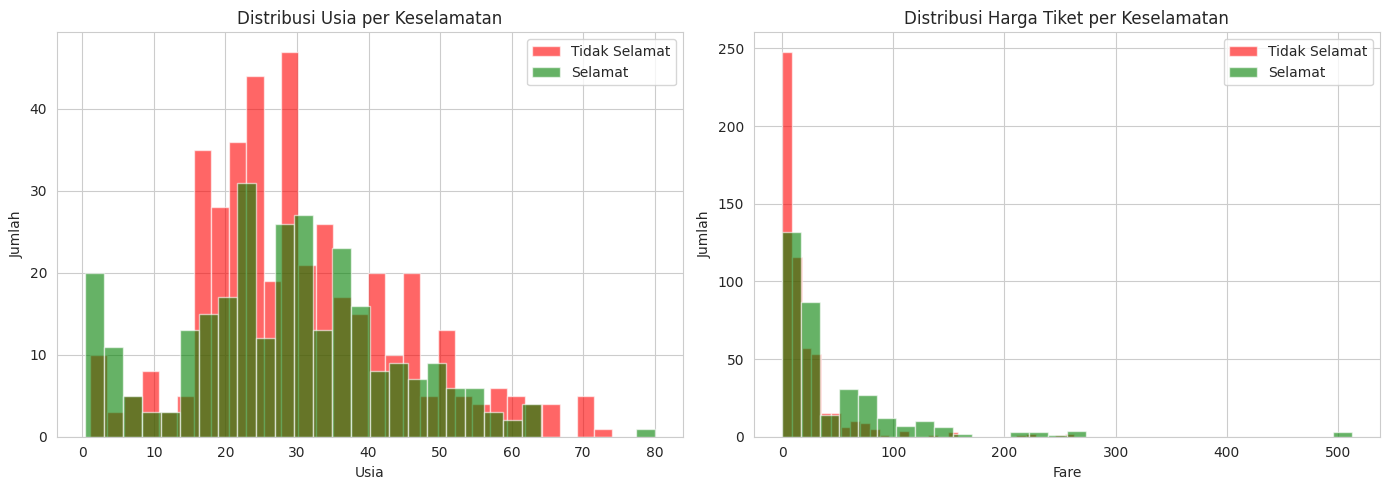

Plot distribusi Age dan Fare tersimpan.


In [9]:
# 4.4 Distribusi Age dan Fare
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age distribution by survival
df[df['Survived'] == 0]['Age'].dropna().hist(bins=30, ax=axes[0], alpha=0.6, color='red', label='Tidak Selamat')
df[df['Survived'] == 1]['Age'].dropna().hist(bins=30, ax=axes[0], alpha=0.6, color='green', label='Selamat')
axes[0].set_title('Distribusi Usia per Keselamatan')
axes[0].set_xlabel('Usia')
axes[0].set_ylabel('Jumlah')
axes[0].legend()

# Fare distribution by survival
df[df['Survived'] == 0]['Fare'].hist(bins=30, ax=axes[1], alpha=0.6, color='red', label='Tidak Selamat')
df[df['Survived'] == 1]['Fare'].hist(bins=30, ax=axes[1], alpha=0.6, color='green', label='Selamat')
axes[1].set_title('Distribusi Harga Tiket per Keselamatan')
axes[1].set_xlabel('Fare')
axes[1].set_ylabel('Jumlah')
axes[1].legend()

plt.tight_layout()
plt.savefig('distribusi_age_fare.png', dpi=100)
plt.show()
print('Plot distribusi Age dan Fare tersimpan.')

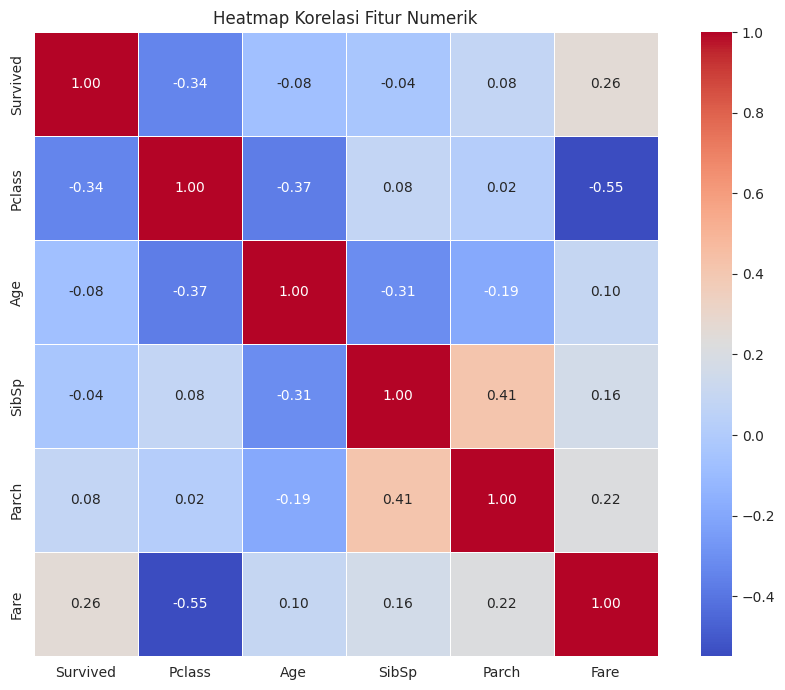

Heatmap tersimpan.


In [10]:
# 4.5 Heatmap Korelasi (fitur numerik)
numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
plt.figure(figsize=(9, 7))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Heatmap Korelasi Fitur Numerik')
plt.tight_layout()
plt.savefig('heatmap_korelasi.png', dpi=100)
plt.show()
print('Heatmap tersimpan.')

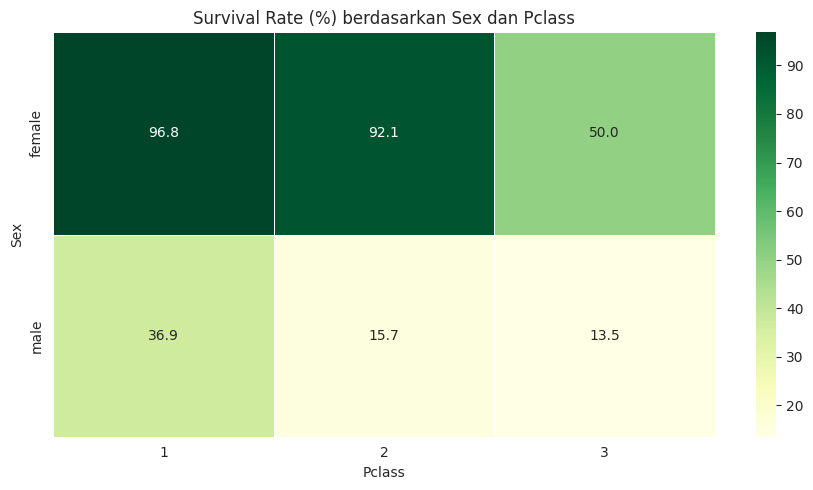

Heatmap Sex vs Pclass tersimpan.


In [11]:
# 4.6 Survival berdasarkan Sex dan Pclass
pivot = df.pivot_table(values='Survived', index='Sex', columns='Pclass', aggfunc='mean') * 100
plt.figure(figsize=(9, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlGn', linewidths=0.5)
plt.title('Survival Rate (%) berdasarkan Sex dan Pclass')
plt.tight_layout()
plt.savefig('survival_sex_pclass.png', dpi=100)
plt.show()
print('Heatmap Sex vs Pclass tersimpan.')

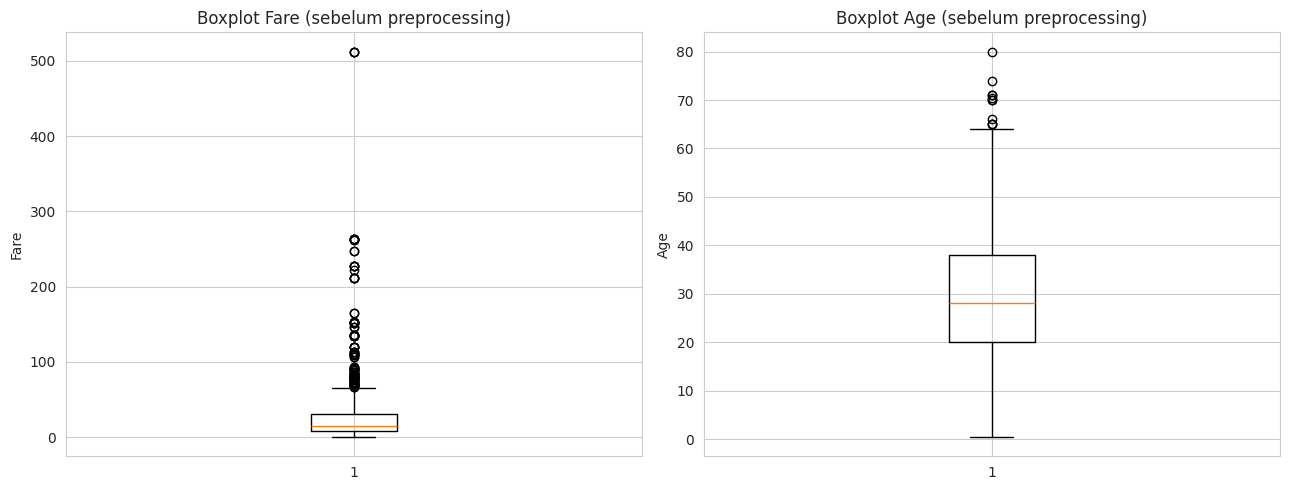

Boxplot outlier tersimpan.

Fare - Max: 512.33, Q3: 31.00, Median: 14.45
Age  - Max: 80.00, Min: 0.42, Median: 28.00


In [12]:
# 4.7 Boxplot Fare (deteksi outlier)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].boxplot(df['Fare'].dropna())
axes[0].set_title('Boxplot Fare (sebelum preprocessing)')
axes[0].set_ylabel('Fare')

axes[1].boxplot(df['Age'].dropna())
axes[1].set_title('Boxplot Age (sebelum preprocessing)')
axes[1].set_ylabel('Age')

plt.tight_layout()
plt.savefig('boxplot_outlier.png', dpi=100)
plt.show()
print('Boxplot outlier tersimpan.')

# Statistik Fare
print(f"\nFare - Max: {df['Fare'].max():.2f}, Q3: {df['Fare'].quantile(0.75):.2f}, Median: {df['Fare'].median():.2f}")
print(f"Age  - Max: {df['Age'].max():.2f}, Min: {df['Age'].min():.2f}, Median: {df['Age'].median():.2f}")

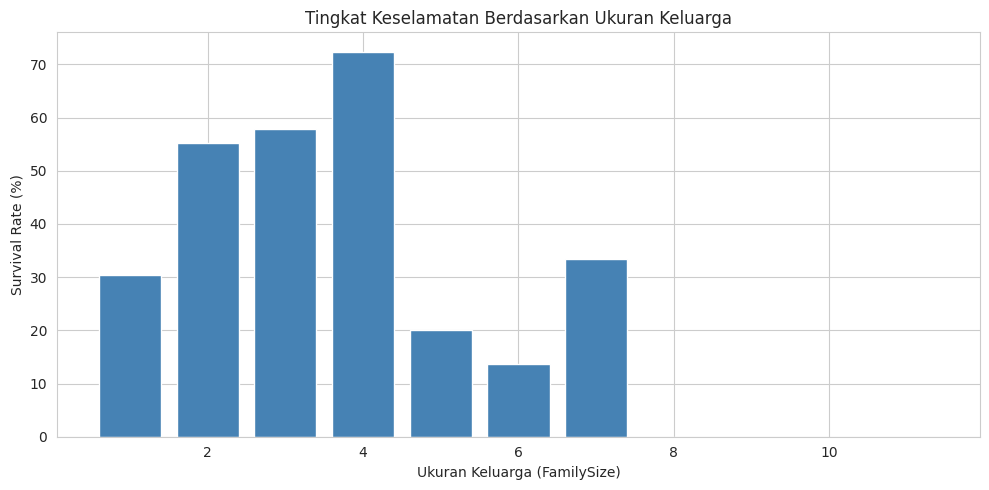

Plot FamilySize tersimpan.


In [13]:
# 4.8 Analisis FamilySize (fitur baru)
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
survival_family = df.groupby('FamilySize')['Survived'].mean() * 100

plt.figure(figsize=(10, 5))
plt.bar(survival_family.index, survival_family.values, color='steelblue')
plt.xlabel('Ukuran Keluarga (FamilySize)')
plt.ylabel('Survival Rate (%)')
plt.title('Tingkat Keselamatan Berdasarkan Ukuran Keluarga')
plt.tight_layout()
plt.savefig('survival_familysize.png', dpi=100)
plt.show()
print('Plot FamilySize tersimpan.')

# 5. Data Preprocessing

Berdasarkan EDA, tahapan preprocessing yang dilakukan:
1. Hapus kolom tidak relevan: `PassengerId`, `Name`, `Ticket`
2. Tangani missing values: `Age` (isi median), `Fare` (isi median)
3. Hapus duplikat
4. Feature engineering: tambah `FamilySize = SibSp + Parch + 1`
5. Encoding kolom `Sex`: male=1, female=0
6. Tangani outlier `Fare` (IQR Clipping)
7. Standarisasi fitur numerik: `Age`, `Fare`, `FamilySize`

In [14]:
df_proc = df.drop(columns=['FamilySize'], errors='ignore').copy()

# 5.1 Hapus kolom tidak relevan
cols_to_drop = ['PassengerId', 'Name', 'Ticket']
df_proc.drop(columns=cols_to_drop, inplace=True)
print(f'Kolom setelah drop: {df_proc.columns.tolist()}')

Kolom setelah drop: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Cabin', 'Embarked']


In [15]:
# 5.2 Tangani Missing Values
age_median = df_proc['Age'].median()
fare_median = df_proc['Fare'].median()

df_proc['Age'].fillna(age_median, inplace=True)
df_proc['Fare'].fillna(fare_median, inplace=True)

print(f'Age  median: {age_median:.2f} | Missing Age  : {df_proc["Age"].isnull().sum()}')
print(f'Fare median: {fare_median:.2f} | Missing Fare : {df_proc["Fare"].isnull().sum()}')

Age  median: 28.00 | Missing Age  : 0
Fare median: 14.45 | Missing Fare : 0


In [16]:
# 5.3 Hapus Duplikat
before = len(df_proc)
df_proc.drop_duplicates(inplace=True)
print(f'Duplikat dihapus: {before - len(df_proc)} baris. Sisa: {len(df_proc)}')

Duplikat dihapus: 110 baris. Sisa: 781


In [17]:
# 5.4 Feature Engineering - FamilySize
df_proc['FamilySize'] = df_proc['SibSp'] + df_proc['Parch'] + 1
print(f'FamilySize dibuat. Distribusi: {df_proc["FamilySize"].value_counts().sort_index().to_dict()}')

FamilySize dibuat. Distribusi: {1: 443, 2: 154, 3: 101, 4: 28, 5: 13, 6: 22, 7: 12, 8: 6, 11: 2}


In [18]:
# 5.5 Encoding Sex
df_proc['Sex'] = df_proc['Sex'].map({'male': 1, 'female': 0})
print(f'Encoding Sex selesai. Nilai unik: {df_proc["Sex"].unique()}')
print(f'Distribusi: {df_proc["Sex"].value_counts().to_dict()}')

Encoding Sex selesai. Nilai unik: [1 0]
Distribusi: {1: 488, 0: 293}


In [19]:
# 5.6 Tangani Outlier Fare (IQR Clipping)
Q1 = df_proc['Fare'].quantile(0.25)
Q3 = df_proc['Fare'].quantile(0.75)
IQR = Q3 - Q1
fare_upper = Q3 + 1.5 * IQR
n_outlier = (df_proc['Fare'] > fare_upper).sum()
df_proc['Fare'] = df_proc['Fare'].clip(upper=fare_upper)
print(f'Fare outlier clipping: {n_outlier} nilai di-clip ke {fare_upper:.2f}')

Fare outlier clipping: 102 nilai di-clip ke 72.98


In [20]:
# 5.7 Standarisasi Fitur Numerik
scale_cols = ['Age', 'Fare', 'FamilySize']
scaler = StandardScaler()
df_proc[scale_cols] = scaler.fit_transform(df_proc[scale_cols])
print(f'Standarisasi selesai untuk kolom: {scale_cols}')
print(df_proc[scale_cols].describe().round(3))

Standarisasi selesai untuk kolom: ['Age', 'Fare', 'FamilySize']
           Age     Fare  FamilySize
count  781.000  781.000     781.000
mean     0.000   -0.000       0.000
std      1.001    1.001       1.001
min     -2.123   -1.167      -0.621
25%     -0.554   -0.812      -0.621
50%     -0.118   -0.466      -0.621
75%      0.464    0.333       0.038
max      3.662    2.050       5.966


In [21]:
# Simpan hasil preprocessing
output_dir = 'titanic_preprocessing'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, 'titanic_preprocessing.csv')
df_proc.to_csv(output_path, index=False)

print(f'Data preprocessing tersimpan: {output_path}')
print(f'Shape final: {df_proc.shape}')
print(f'Kolom final: {df_proc.columns.tolist()}')
print()
df_proc.head()

Data preprocessing tersimpan: titanic_preprocessing/titanic_preprocessing.csv
Shape final: (781, 10)
Kolom final: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Cabin', 'Embarked', 'FamilySize']



,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,FamilySize
0,0,3,1,-0.554151,1,0,-0.847158,NaN,S,0.037949
1,1,1,0,0.608990,1,0,1.975081,C85,C,0.037949
2,1,3,0,-0.263365,0,0,-0.817408,NaN,S,-0.620679
3,1,1,0,0.390901,1,0,1.173660,C123,S,0.037949
4,0,3,1,0.390901,0,0,-0.811898,NaN,S,-0.620679


In [22]:
# Verifikasi split
X = df_proc.drop('Survived', axis=1)
y = df_proc['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('=== Verifikasi Data Split ===')
print(f'Total    : {len(df_proc)}')
print(f'Train    : {len(X_train)} ({len(X_train)/len(df_proc)*100:.1f}%)')
print(f'Test     : {len(X_test)} ({len(X_test)/len(df_proc)*100:.1f}%)')
print(f'Train target: {dict(y_train.value_counts().sort_index())}')
print(f'Test  target: {dict(y_test.value_counts().sort_index())}')
print('\nData siap untuk pelatihan model!')

=== Verifikasi Data Split ===
Total    : 781
Train    : 624 (79.9%)
Test     : 157 (20.1%)
Train target: {0: np.int64(366), 1: np.int64(258)}
Test  target: {0: np.int64(92), 1: np.int64(65)}

Data siap untuk pelatihan model!
